<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/Projects/Project-5/Wiki_Pass_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Wikipedia NLP Clustering

##Problem Definition

The goal of this project is to use Natural Language Processing (NLP) to identify the ten most similar people based on their biographies. After cleaning and preprocessing the text, TF-IDF is used to convert biographies into numerical features, and K-Nearest Neighbors (KNN) is used to measure similarity between individuals. Sentiment analysis is performed on the reference person’s biography, and similarity rankings from DBpedia summaries are compared with rankings from full Wikipedia articles. Finally, an interactive notebook allows users to select a person and view their ten closest matches.

##Data Collection

In [32]:
%%capture install_output
%%bash

#Install necessary NLP and Wikipedia API libraries
pip install -q -U textblob wikipedia-api
#Download TextBlob for NLP tasks
python -m textblob.download_corpora

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import wikipediaapi
import ipywidgets as widgets #Used to create dropdown and button
import urllib.parse #Used to decode special (foreign) characters

from textblob import TextBlob #Tokenization, Counting words, Parts of Speech Sentiment Analysis
from sklearn.feature_extraction.text import CountVectorizer #Understand Bag of Words
from sklearn.feature_extraction.text import TfidfVectorizer #Final Representation
from sklearn.neighbors import NearestNeighbors #Primary algorithm
from IPython.display import display #Pushes widgets to screen

In [34]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv'

In [35]:
df = pd.read_csv(url)
df

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...
...,...,...,...
42781,<http://dbpedia.org/resource/Motoaki_Takenouchi>,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,<http://dbpedia.org/resource/Alan_Judge_(footb...,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,<http://dbpedia.org/resource/Eduardo_Lara>,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,<http://dbpedia.org/resource/Tatiana_Faberg%C3...,Tatiana Faberg%C3%A9,tatiana faberg is an author and faberg scholar...


##Data Cleaning

In [36]:
df.shape

(42786, 3)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42786 entries, 0 to 42785
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URI     42786 non-null  object
 1   name    42786 non-null  object
 2   text    42786 non-null  object
dtypes: object(3)
memory usage: 1002.9+ KB


###Missing Values

In [38]:
df.isnull().sum()

,0
URI,0
name,0
text,0


###Duplicates

In [39]:
# Duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

# Duplicate URIs
print(f"Duplicate URIs: {df['URI'].duplicated().sum()}")

# Duplicate names
print(f"Duplicate names: {df['name'].duplicated().sum()}")

# Duplicate biographies
print(f"Duplicate biographies: {df['text'].duplicated().sum()}")

Duplicate rows: 0
Duplicate URIs: 0
Duplicate names: 1
Duplicate biographies: 0


In [43]:
#View rows with duplicate names
df[df['name'].duplicated(keep=False)]

,URI,name,text
787,<http://dbpedia.org/resource/James_Grieve_(tra...,author),james grieve born 1934 is an australian transl...
17249,<http://dbpedia.org/resource/Steve_Greenberg_(...,author),steve greenberg december 20 1960 is an america...


In [44]:
#Extract names from the URI
extracted_names = (
    df["URI"]
    #Extract between resource/ and next parenthesis
    .str.extract(r"resource/([^(\n]+)")[0]
    .str.replace("_", " ", regex=False)
    .str.strip()
)

#Identify invalid names
mask = df["name"].str.contains(
    r"^author\)$",
    regex=True,
    na=False
)

#Replace invalid names
df.loc[mask, "name"] = extracted_names[mask]

In [45]:
#Verify Corrections
df[df['name'].str.contains(r'^author\)$', na=False)]

,URI,name,text


###Name Cleaning

In [46]:
#Unique names
print(f"Unique names: {df['name'].nunique():,}")

#Missing values
print(f"Missing names: {df['name'].isnull().sum()}")

#Create working copy
df["clean_name"] = df["name"]

Unique names: 42,786
Missing names: 0


####Remove Extra Whitespace

In [47]:
df['clean_name'] = (
    df['clean_name']
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

####Decode URL-Encoded Characters

In [48]:
df['clean_name'] = df['name'].apply(urllib.parse.unquote)

In [50]:
#Validate Name Cleaning
df[df['name'].str.contains('Javier S', case=False, na=False)][
    ['name', 'clean_name', 'text']
]

,name,clean_name,text
10133,Javier S%C3%A1nchez,Javier Sánchez,javier snchez vicario born 1968 in pamplona sp...
34536,Javier Santiso,Javier Santiso,javier santiso is a young global leader ygl of...


####Check Duplicate Clean Names

In [51]:
print(f"Duplicate clean names: {df['clean_name'].duplicated().sum()}")

Duplicate clean names: 0


In [52]:
df[df['clean_name'].duplicated(keep=False)]

,URI,name,text,clean_name


###Text Cleaning

In [53]:
#Create working copy
df["clean_text"] = df["text"]

#Missing values
print(f"Missing biographies: {df['text'].isnull().sum()}")

#Remove whitespace?????
print(f"Blank biographies: {(df['text'].str.strip() == '').sum()}")

Missing biographies: 0
Blank biographies: 0


In [28]:
#Calculate length of text
df["text_length"] = df["text"].apply(len)

df["text_length"].describe().transpose()

,text_length
count,42786.000000
mean,1896.548801
std,833.085754
min,1049.000000
25%,1386.000000
50%,1655.000000
75%,2125.000000
max,31850.000000


####Convert to Lowercase

In [29]:
df["clean_text"] = df["clean_text"].str.lower()

####Remove Punctuation

In [54]:
df["clean_text"] = (
    df["clean_text"]
    #Means keep words and spaces, remove everything else
    .str.replace(r"[^\w\s]", "", regex=True)
)

####Remove Extra Whitespaces

In [59]:
df["clean_text"] = (
    df["clean_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

####Lemmatization

In [56]:
df["clean_text"] = df["clean_text"].apply(
    lambda text: " ".join(
        word.lemmatize()
        for word in TextBlob(text).words
    )
)

In [58]:
#Compare single biography
person_name = "Digby Morrell"

original = df.loc[
    df["clean_name"] == person_name,
    "text"
].iloc[0]

cleaned = df.loc[
    df["clean_name"] == person_name,
    "clean_text"
].iloc[0]

print("Original:\n")
print(original)

print("\n" + "-"*80 + "\n")

print("Cleaned:\n")
print(cleaned)

Original:

digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play victorian football league vfl football with the northern bullants car

##Create Clean DataFrame

In [61]:
df_clean = df[['clean_name', 'clean_text']].copy()
df_clean

,clean_name,clean_text
0,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,G-Enka,henry krvits born 30 december 1974 in tallinn ...
...,...,...
42781,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,Tatiana Fabergé,tatiana faberg is an author and faberg scholar...


#NLP Preprocessing

##Part 1 - Reference Person

1. Pick one person from the list ( the reference person ) and output 10 other people who's overview are "closest" to the reference person in a Natural Language Processing sense
2. Also output the sentiment of the overview of the reference person


In [62]:
df_clean['clean_name'].sample(1)

,clean_name
33115,Tony Capizzi


In [83]:
#Enter sample person
reference_person = 'Tony Capizzi'

#Verify person exists
person = df_clean[df_clean['clean_name'] == reference_person]

if person.empty:
  print('Person not found.')
else:
  reference_text = person['clean_text'].iloc[0]

  print('Reference Person:')
  print(reference_person)

Reference Person:
Tony Capizzi


###Sentiment

In [84]:
#Create TextBlob
blob = TextBlob(reference_text)

#Display sentences
print('Sentences:')
for sentence in blob.sentences:
  print(sentence)

Sentences:
anthony capizzi is an american politician from the state of ohio he is a democratcapizzi received his bachelor of art from st bonaventure university in 1975 and his jd from the university of dayton school of law in 1979 he wa admitted to the ohio and federal bar the same year capizzi wa in private practice with the law firm of harker capizzi hall for 25 year specializing in juvenile and family law litigation capizzi served a a member of the dayton city commission of dayton ohio from 1986 to 1998 during his tenure on the city commission capizzis most prominent role wa his effort to get a minor league baseball team for dayton his dream finally came true with the formation of the dayton dragon in 1997 capizzi wa the democratic nominee for the office of dayton mayor however he lost to incumbent republican michael r mike turner in 2000 capizzi ran in a special election for a seat on the montgomery county court of common plea he lost to republican michael t hall in 2004 he ran aga

###TF-IDF Text Representation


**Why TF-IDF?** It gives more importance to meaningful words and less importance to common words like "the", "and", and "of". This makes biographies easier to compare.

In [85]:
#Convert biographies into numerical vectors
#Remove stop words (words that do not add meaning)
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df_clean['clean_text'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (42786, 423641)


###Similarity Search (KNN)

In [86]:
#Create KNN similarity model
knn = NearestNeighbors(
    n_neighbors=11,
    #Asks 'Do these biographies point in the same direction?'
    metric='cosine'
)

knn.fit(tfidf_matrix)


#Find index of reference person
reference_index = df_clean.index[
    df_clean['clean_name'] == reference_person
][0]


#Find closest biographies
distances, indices = knn.kneighbors(
    tfidf_matrix[reference_index]
)


#Display top 10 similar people
similar_people = pd.DataFrame({
    'Name': df_clean.iloc[indices[0][1:]]['clean_name'].values,
    'Similarity Distance': distances[0][1:]
})

similar_people

,Name,Similarity Distance
0,Mark Dayton,0.731391
1,Roosevelt Chapman,0.791750
2,Sandy Bashaw,0.793888
3,Chuck Curran,0.817522
4,Bill Uhl,0.828705
5,Michael H. Watson,0.830415
6,Miguel H. Díaz,0.840856
7,Paul Ramon Matia,0.842723
8,Rhine McLin,0.849444
9,Chris Harris (basketball),0.849536


###Sentiment Analysis

In [87]:
#Extract sentiment scores
sentiment = blob.sentiment


print("Reference Person:", reference_person)
print("Polarity Score:", sentiment.polarity)
print("Subjectivity Score:", sentiment.subjectivity)


#Convert polarity into sentiment label
if sentiment.polarity > 0:
    label = 'Positive'
elif sentiment.polarity < 0:
    label = 'Negative'
else:
    label = 'Neutral'


print("Sentiment:", label)

Reference Person: Tony Capizzi
Polarity Score: 0.0738095238095238
Subjectivity Score: 0.4847619047619048
Sentiment: Positive


###Convert Distance to Similarity

In [88]:
similar_people['Similarity Score'] = 1 - similar_people['Similarity Distance']
similar_people.sort_values(
    'Similarity Score',
    ascending=False
)

,Name,Similarity Distance,Similarity Score
0,Mark Dayton,0.731391,0.268609
1,Roosevelt Chapman,0.791750,0.208250
2,Sandy Bashaw,0.793888,0.206112
3,Chuck Curran,0.817522,0.182478
4,Bill Uhl,0.828705,0.171295
5,Michael H. Watson,0.830415,0.169585
6,Miguel H. Díaz,0.840856,0.159144
7,Paul Ramon Matia,0.842723,0.157277
8,Rhine McLin,0.849444,0.150556
9,Chris Harris (basketball),0.849536,0.150464


**Why use Cosine Similarity instead of another metric?**
- Euclidean Distance (straight-line distance) "These are far apart because the numbers are bigger."
- Cosine ignores the size and focuses on the pattern of words.

##Part 2 - Wikipedia

1. Print out the text of the Wikipedia article for the reference person
2. Determine the sentiment of the text of the Wikipedia page for the reference person
1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1
1. Determine the nearness ranking of these 10 people to your reference person based on their entire Wikipedia page
1. Compare, i.e. plot, the nearest ranking from Step 1) with the Wikipedia page nearness ranking. A difference of the rank is one means of comparison.

In [89]:
wiki = wikipediaapi.Wikipedia(
    user_agent='NLP_Project/1.0',
    language='en'
)

###Retrieve Wikipedia Page for Reference Person

In [90]:
#Get Wikipedia page for reference person
reference_page = wiki.page(reference_person)


if reference_page.exists():
    print("Wikipedia page found.")
else:
    print("Wikipedia page not found.")


#Store Wikipedia text
reference_wiki = reference_page.text


#Display first 1000 characters
print(reference_wiki[:1000])

Wikipedia page not found.



###Sentiment Analysis of Wikipedia Article

In [91]:
#Create TextBlob
wiki_blob = TextBlob(reference_wiki)


#Extract sentiment
wiki_sentiment = wiki_blob.sentiment

print('Reference Person:', reference_person)
print('Wikipedia Polarity:', wiki_blob.sentiment.polarity)
print('Wikipedia Subjectivity:', wiki_blob.sentiment.subjectivity)

Reference Person: Tony Capizzi
Wikipedia Polarity: 0.0
Wikipedia Subjectivity: 0.0


**Explanation:**
- **Polarity** measures whether the text is positive or negative.
  * -1 = very negative
  * 0 = neutral
  * +1 = very positive
- **Subjectivity** measures whether the text is opinion-based.
  * 0 = factual/objective
  * 1 = opinion-based

Wikipedia pages should generally have:

- polarity close to 0
- low subjectivity

because they are written as biographies, not reviews.

###Collect Wikipedia Pages for Top 10 Similar People

In [92]:
#Store Wikipedia articles
wiki_texts = []


for name in similar_people['Name']:

    person_page = wiki.page(name)

    if person_page.exists():
        wiki_texts.append(person_page.text)
    else:
        wiki_texts.append("")


#Create dataframe
wiki_df = similar_people.copy()

wiki_df['Wikipedia_Text'] = wiki_texts


wiki_df.head()

,Name,Similarity Distance,Similarity Score,Wikipedia_Text
0,Mark Dayton,0.731391,0.268609,"Mark Brandt Dayton (born January 26, 1947) is ..."
1,Roosevelt Chapman,0.791750,0.208250,"Roosevelt ""Velvet"" Chapman (born April 6, 1962..."
2,Sandy Bashaw,0.793888,0.206112,
3,Chuck Curran,0.817522,0.182478,"Charles J. Curran (born June 1, 1939, in Galio..."
4,Bill Uhl,0.828705,0.171295,"William George Uhl Sr. (January 7, 1933 – Dece..."


###Combine Reference Person + Similar People

In [93]:
comparison_df = pd.DataFrame({
    'Name': [reference_person] + wiki_df['Name'].tolist(),
    'Text': [reference_wiki] + wiki_df['Wikipedia_Text'].tolist()
})

comparison_df.head()

,Name,Text
0,Tony Capizzi,
1,Mark Dayton,"Mark Brandt Dayton (born January 26, 1947) is ..."
2,Roosevelt Chapman,"Roosevelt ""Velvet"" Chapman (born April 6, 1962..."
3,Sandy Bashaw,
4,Chuck Curran,"Charles J. Curran (born June 1, 1939, in Galio..."


###Convert Wikipedia Pages into TF-IDF Vectors

In [94]:
#Create TF-IDF model
wiki_tfidf = TfidfVectorizer(
    stop_words='english'
)

# Convert Wikipedia text into numerical vectors
wiki_matrix = wiki_tfidf.fit_transform(
    comparison_df['Text']
)

print("Wikipedia TF-IDF Shape:", wiki_matrix.shape)

Wikipedia TF-IDF Shape: (11, 1766)


###Find Wikipedia Similarity Ranking

In [95]:
#Create KNN model
wiki_knn = NearestNeighbors(
    n_neighbors=11,
    metric='cosine'
)

wiki_knn.fit(wiki_matrix)

#Find closest Wikipedia articles
wiki_distances, wiki_indices = wiki_knn.kneighbors(
    wiki_matrix[0]
)

#Create ranking dataframe
wiki_results = pd.DataFrame({
    'Wikipedia Rank': range(1, 11),
    'Name': comparison_df.iloc[wiki_indices[0][1:]]['Name'].values,
    'Wikipedia Distance': wiki_distances[0][1:]
})

#Convert distance to similarity
wiki_results['Wikipedia Similarity'] = (
    1 - wiki_results['Wikipedia Distance']
)

wiki_results

,Wikipedia Rank,Name,Wikipedia Distance,Wikipedia Similarity
0,1,Mark Dayton,1.0,0.0
1,2,Roosevelt Chapman,1.0,0.0
2,3,Sandy Bashaw,1.0,0.0
3,4,Chuck Curran,1.0,0.0
4,5,Bill Uhl,1.0,0.0
5,6,Michael H. Watson,1.0,0.0
6,7,Miguel H. Díaz,1.0,0.0
7,8,Paul Ramon Matia,1.0,0.0
8,9,Rhine McLin,1.0,0.0
9,10,Chris Harris (basketball),1.0,0.0


###Compare Part 1 Ranking vs Wikipedia Ranking

In [96]:
#Part 1 Ranking
part1_ranks = similar_people[['Name']].copy()

part1_ranks['TF-IDF Rank'] = range(
    1,
    len(part1_ranks) + 1
)

#Merge rankings
comparison = part1_ranks.merge(
    wiki_results[['Name','Wikipedia Rank']],
    on='Name'
)

comparison

,Name,TF-IDF Rank,Wikipedia Rank
0,Mark Dayton,1,1
1,Roosevelt Chapman,2,2
2,Sandy Bashaw,3,3
3,Chuck Curran,4,4
4,Bill Uhl,5,5
5,Michael H. Watson,6,6
6,Miguel H. Díaz,7,7
7,Paul Ramon Matia,8,8
8,Rhine McLin,9,9
9,Chris Harris (basketball),10,10


###Calculate Rank Difference

In [97]:
comparison['Rank Difference'] = (
    comparison['TF-IDF Rank'] -
    comparison['Wikipedia Rank']
).abs()


comparison

,Name,TF-IDF Rank,Wikipedia Rank,Rank Difference
0,Mark Dayton,1,1,0
1,Roosevelt Chapman,2,2,0
2,Sandy Bashaw,3,3,0
3,Chuck Curran,4,4,0
4,Bill Uhl,5,5,0
5,Michael H. Watson,6,6,0
6,Miguel H. Díaz,7,7,0
7,Paul Ramon Matia,8,8,0
8,Rhine McLin,9,9,0
9,Chris Harris (basketball),10,10,0


###Plot Ranking Differences

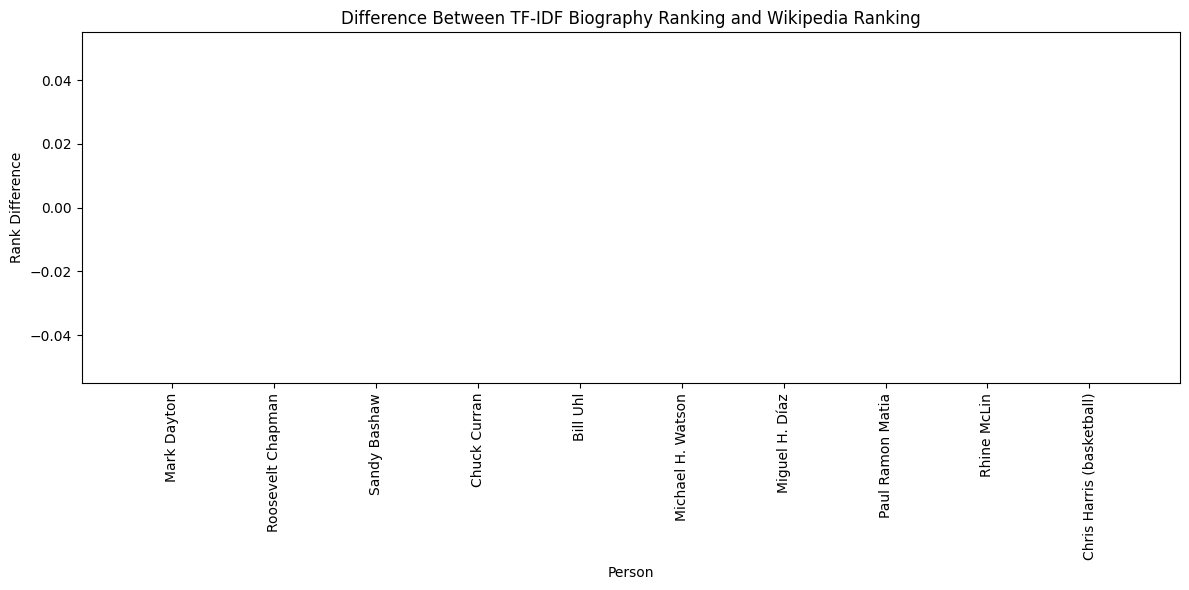

In [98]:
plt.figure(figsize=(12,6))

plt.bar(comparison['Name'], comparison['Rank Difference'])

plt.xticks(rotation=90)
plt.ylabel('Rank Difference')
plt.xlabel('Person')
plt.title('Difference Between TF-IDF Biography Ranking and Wikipedia Ranking')

plt.tight_layout()

plt.show()

##Part 3 - Interactive Notebook

In [100]:
#Create function
def find_similar_people(person_name):

  #Check if the person exists
  if person_name not in df_clean['clean_name'].values:
    print(f"'{person_name}' was not found in the dataset.")
    return

  #Find the reference person's index
  reference_index = df_clean[df_clean['clean_name'] == person_name].index[0]

  #Find 10 nearest neighbors
  distances, indices = knn.kneighbors(tfidf_matrix[reference_index])

  #Get biography of reference person's
  reference_text = df_clean.loc[df_clean['clean_name'] == person_name, 'clean_text'].iloc[0]

  #Sentiment Analysis
  blob = TextBlob(reference_text)

  #Create results DataFrame
  results = pd.DataFrame({
      'Name': df_clean.iloc[indices[0][1:]]['clean_name'].values,
      'Distance': distances[0][1:]
  })

  #Convert distance to similarity score
  results['Similarity Score'] = (1 - results['Distance'])

  #Display results
  print('=' * 60)
  print(f"Reference Person: {person_name}")
  print('=' * 60)

  print(f'Polarity: {blob.sentiment.polarity:.3f}')
  print(f'Subjectivity: {blob.sentiment.subjectivity:.3f}')
  print()

  print('10 Closest Individuals')

  display(results.sort_values('Similarity Score', ascending=False))

#Create searchable text box
person_input = widgets.Combobox(
    placeholder="Type a person's name: ",
    options=sorted(df_clean['clean_name'].unique()),
    description='Person:',
    ensure_option=False,
    layout=widgets.Layout(width='450px')
)

#Create button
button = widgets.Button(
    description='Find Similar People',
    button_style='success'
)

#Button action
def on_button_clicked(b):
  find_similar_people(person_input.value)

button.on_click(on_button_clicked)

#Display widgets
display(person_input)
display(button)

Combobox(value='', description='Person:', layout=Layout(width='450px'), options=(' Renate Lorenz', "'Ilima Lei…

Button(button_style='success', description='Find Similar People', style=ButtonStyle())